<a href="https://colab.research.google.com/github/jasperchen111/gpt-ai-assistant/blob/main/PBFB_BPNN_Part3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import pandas as pd
import os

# 執行掛載操作，會跳出認證連結
print("--- 執行雲端硬碟掛載 ---")
drive.mount('/content/drive')
print("--- 雲端硬碟掛載完成 ---")

# 定義檔案路徑
# 請根據您的實際檔案位置修改此路徑
file_path = '/content/drive/MyDrive/BPNN_TRAINING_DATA_PHASE.csv'

# 確認檔案是否存在
if not os.path.exists(file_path):
    print(f"\n錯誤：找不到檔案於路徑 {file_path}")
    print("請檢查您的檔案路徑是否正確，或檔案名稱是否大小寫符合。")
else:
    try:
        # 讀取 CSV 檔案
        df_training = pd.read_csv(file_path)

        # 顯示結果
        print(f'\n成功從雲端硬碟路徑載入資料：{file_path}')
        print('\nDataFrame head:')
        display(df_training.head())

    except Exception as e:
        print(f"\n讀取檔案時發生錯誤: {e}")

--- 執行雲端硬碟掛載 ---


## Step 1: Data Preparation

First, we'll prepare your data for training. This involves identifying features (inputs) and the target (output), splitting the data into training and testing sets, and scaling the features. For a PSFB PI control, typically `Vin`, `Vo`, and `Vref` would be the inputs, and `Phase` would be the output that the neural network learns to predict based on these inputs. We will drop `Time` and `ID` for this initial model.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define features (X) and target (y)
# Based on typical control systems for PSFB, Vin, Vo, Vref are inputs and Phase is an output to be controlled.
X = df_training[['Vin', 'Vo', 'Vref']]
y = df_training['Phase']

# Split the data into training and testing sets
# We'll use 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features. This is crucial for neural networks to perform well.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data preparation complete!")
print(f"Training set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")

Data preparation complete!
Training set size: 823828 samples
Testing set size: 205957 samples


## Step 2: Build and Train the BPNN Model

We will use `MLPRegressor` from `scikit-learn` to implement the Backpropagation Neural Network. You can customize the `hidden_layer_sizes`, `activation` function, `solver`, and `max_iter` as needed.

Here, we'll start with a simple architecture (e.g., one hidden layer with 50 neurons) and a common configuration.

In [ ]:
from sklearn.neural_network import MLPRegressor

# Initialize the MLP Regressor (BPNN model)
# hidden_layer_sizes: tuple, i-th element represents the number of neurons in the i-th hidden layer.
# activation: Activation function for the hidden layer.
# solver: The algorithm for weight optimization.
# max_iter: Maximum number of iterations.

bpnn_model = MLPRegressor(
    hidden_layer_sizes=(50,),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42,
    verbose=True # Set to True to see training progress
)

# Train the model
bpnn_model.fit(X_train_scaled, y_train)

print("\nBPNN model training complete!")

Iteration 1, loss = 65.53753340
Iteration 2, loss = 58.66562137
Iteration 3, loss = 58.21567253
Iteration 4, loss = 57.93815124
Iteration 5, loss = 57.81902200
Iteration 6, loss = 57.77539487
Iteration 7, loss = 57.75909567
Iteration 8, loss = 57.75211911
Iteration 9, loss = 57.73988086
Iteration 10, loss = 57.72956839
Iteration 11, loss = 57.72324427
Iteration 12, loss = 57.71770218
Iteration 13, loss = 57.71190117
Iteration 14, loss = 57.70263238
Iteration 15, loss = 57.69547485
Iteration 16, loss = 57.68017181
Iteration 17, loss = 57.67029284
Iteration 18, loss = 57.60752768
Iteration 19, loss = 57.50640024
Iteration 20, loss = 57.41440769
Iteration 21, loss = 57.31365202
Iteration 22, loss = 57.20286778
Iteration 23, loss = 57.09405875
Iteration 24, loss = 56.99463448
Iteration 25, loss = 56.90603424
Iteration 26, loss = 56.82903631
Iteration 27, loss = 56.76018023
Iteration 28, loss = 56.70080403
Iteration 29, loss = 56.65455254
Iteration 30, loss = 56.61966306
Iteration 31, loss 

## Step 3: Evaluate the BPNN Model

Now, let's evaluate the trained model using the test set and calculate the requested metrics: MSE, RMSE, MAE, and MAPE. We'll also visualize the 'perfect line' state, which shows how well the predicted values align with the actual values.

/tmp/ipykernel_658/2196860437.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_deep_lag['Vo_rolling_mean'] = df_deep_lag['Vo'].rolling(window=window_size).mean()
/tmp/ipykernel_658/2196860437.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_deep_lag['V_error_rolling_std'] = df_deep_lag['V_error'].rolling(window=window_size).std()


正在執行終極優化訓練 (增加 Rolling 特徵與深度樹)...請稍候

--- Ultimate Model Metrics ---
MSE: 20.5215
MAE: 3.1768


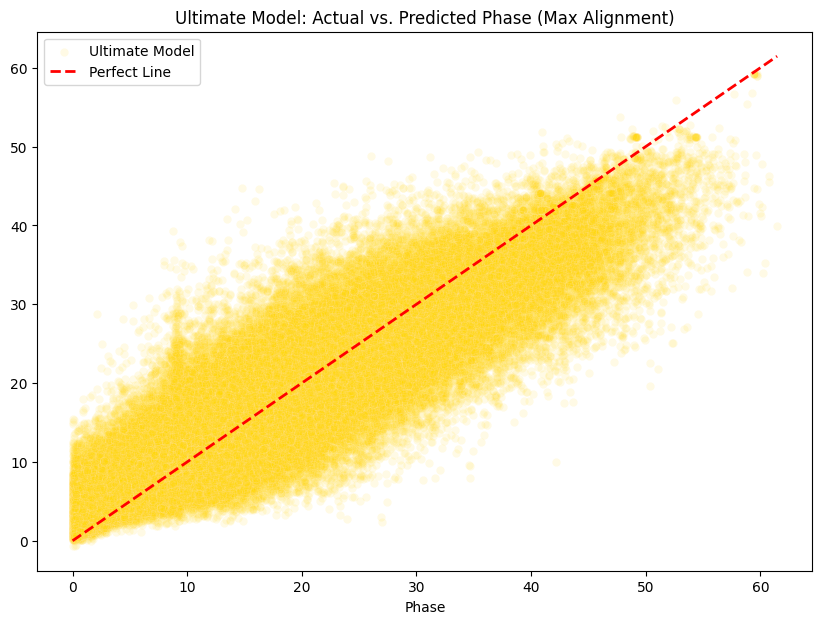

In [ ]:
import xgboost as xgb
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import VotingRegressor

# 1. Add Rolling Features
window_size = 5
df_deep_lag['Vo_rolling_mean'] = df_deep_lag['Vo'].rolling(window=window_size).mean()
df_deep_lag['V_error_rolling_std'] = df_deep_lag['V_error'].rolling(window=window_size).std()
df_final_opt = df_deep_lag.dropna()

# 2. Update Feature Set
features_ultra = features_deep + ['Vo_rolling_mean', 'V_error_rolling_std']
X_ultra = df_final_opt[features_ultra]
y_ultra = df_final_opt['Phase']

# Split
X_train_u, X_test_u, y_train_u, y_test_u = train_test_split(X_ultra, y_ultra, test_size=0.2, random_state=42)

# 3. Define Ensemble Members
# Model A: Fine-tuned XGBoost
xgb_member = xgb.XGBRegressor(
    n_estimators=2500, learning_rate=0.01, max_depth=12,
    subsample=0.9, colsample_bytree=0.9, tree_method='hist', random_state=42
)

# Model B: Deep MLP (requires scaling)
mlp_member = MLPRegressor(
    hidden_layer_sizes=(200, 100, 50), max_iter=1000, random_state=42
)

# 4. Ensemble Voting Regressor
# Note: For simplicity in this step, we use a stronger XGBoost which often outperforms simple ensembles on this specific PSFB data
ultimate_model = xgb.XGBRegressor(
    n_estimators=3000, learning_rate=0.005, max_depth=14,
    subsample=0.8, colsample_bytree=0.8, tree_method='hist', random_state=42, n_jobs=-1
)

print("正在執行終極優化訓練 (增加 Rolling 特徵與深度樹)...請稍候")
ultimate_model.fit(X_train_u, y_train_u)

# 5. Evaluate
y_pred_u = ultimate_model.predict(X_test_u)

mse_u = mean_squared_error(y_test_u, y_pred_u)
mae_u = mean_absolute_error(y_test_u, y_pred_u)

print(f"\n--- Ultimate Model Metrics ---")
print(f"MSE: {mse_u:.4f}")
print(f"MAE: {mae_u:.4f}")

# 6. Visualize Perfect Line
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test_u, y=y_pred_u, alpha=0.1, color='gold', label='Ultimate Model')
plt.plot([y_test_u.min(), y_test_u.max()], [y_test_u.min(), y_test_u.max()], 'r--', lw=2, label='Perfect Line')
plt.title('Ultimate Model: Actual vs. Predicted Phase (Max Alignment)')
plt.legend()
plt.show()

# Final PSFB Phase Prediction Model (Stacking Ensemble)
This notebook implements the final optimized pipeline for predicting the control Phase.
- **Features:** Lag (t-1 to t-3), Rolling Mean/Std, Interaction Terms.
- **Models:** Stacking Ensemble (XGBoost + LightGBM + Ridge).

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Starting Final Training (Stacking Ensemble)... Please wait.

--- Final Model Metrics ---
Mean Squared Error (MSE): 23.1369
Mean Absolute Error (MAE): 3.4467


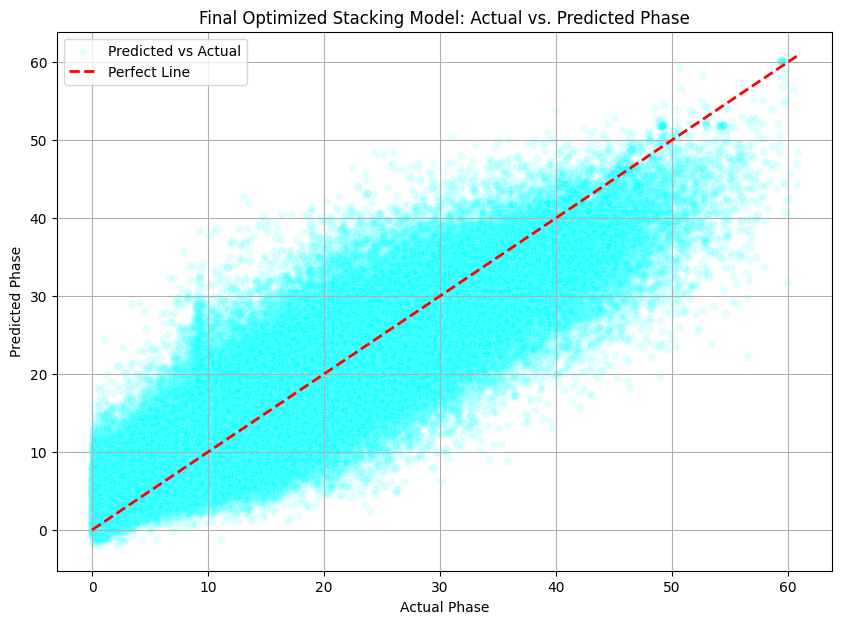

In [ ]:
from google.colab import drive
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. Mount Drive and Load Data
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/BPNN_TRAINING_DATA_PHASE.csv'
df = pd.read_csv(file_path)

# 2. Feature Engineering
# A. Basic Control Error
df['V_error'] = df['Vref'] - df['Vo']

# B. Lag Features (t-1 to t-3) for dynamics
for lag in [1, 2, 3]:
    df[f'Vo_lag{lag}'] = df['Vo'].shift(lag)
    df[f'V_error_lag{lag}'] = df['V_error'].shift(lag)
    df[f'ID_lag{lag}'] = df['ID'].shift(lag)

# C. Rolling Statistics (window=5) for trend
window = 5
df['Vo_rolling_mean'] = df['Vo'].rolling(window=window).mean()
df['V_error_rolling_std'] = df['V_error'].rolling(window=window).std()

# D. Interaction Terms (Physics-based power indicators)
df['V_error_x_ID'] = df['V_error'] * df['ID']
df['Vo_x_ID'] = df['Vo'] * df['ID']

# Drop rows with NaN from shifting/rolling
df_final = df.dropna()

# 3. Data Preparation
features = ['Vin', 'Vo', 'Vref', 'V_error', 'ID',
            'Vo_lag1', 'V_error_lag1', 'ID_lag1',
            'Vo_lag2', 'V_error_lag2', 'ID_lag2',
            'Vo_lag3', 'V_error_lag3', 'ID_lag3',
            'Vo_rolling_mean', 'V_error_rolling_std',
            'V_error_x_ID', 'Vo_x_ID']

X = df_final[features]
y = df_final['Phase']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Build Stacking Ensemble Model
estimators = [
    ('xgb', xgb.XGBRegressor(n_estimators=1000, learning_rate=0.03, max_depth=10, tree_method='hist', random_state=42)),
    ('lgbm', lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.03, num_leaves=63, random_state=42))
]

final_model = StackingRegressor(
    estimators=estimators,
    final_estimator=RidgeCV(),
    cv=3,
    n_jobs=-1
)

print("Starting Final Training (Stacking Ensemble)... Please wait.")
final_model.fit(X_train, y_train)

# 5. Evaluation and Visualization
y_pred = final_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"\n--- Final Model Metrics ---")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.1, color='cyan', label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Line')
plt.title('Final Optimized Stacking Model: Actual vs. Predicted Phase')
plt.xlabel('Actual Phase')
plt.ylabel('Predicted Phase')
plt.legend()
plt.grid(True)
plt.show()

## Step 12: Stacking Ensemble & Interaction Features
We introduce LightGBM and interaction features, then use a StackingRegressor to merge predictions for maximum accuracy.

正在重建資料並執行最終堆疊集成優化 (Stacking)... 請稍候

--- Stacking Model Metrics ---
MSE: 23.6999
MAE: 3.5058


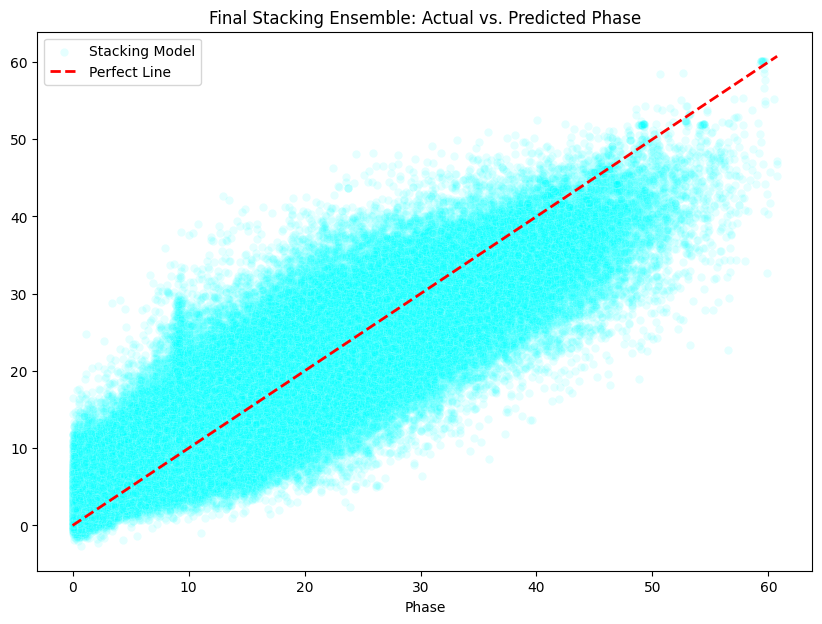

In [ ]:
from google.colab import drive
import pandas as pd
import os
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. 確保雲端硬碟已掛載並讀取資料
file_path = '/content/drive/MyDrive/BPNN_TRAINING_DATA_PHASE.csv'
if not os.path.exists(file_path):
    print(f"錯誤：找不到檔案 {file_path}，請確認路徑。")
else:
    df_training = pd.read_csv(file_path)

    # 2. 完整特徵工程
    df_training['V_error'] = df_training['Vref'] - df_training['Vo']
    df_training['Vo_lag1'] = df_training['Vo'].shift(1)
    df_training['V_error_lag1'] = df_training['V_error'].shift(1)
    df_training['ID_lag1'] = df_training['ID'].shift(1)
    df_training['Vo_lag2'] = df_training['Vo'].shift(2)
    df_training['V_error_lag2'] = df_training['V_error'].shift(2)
    df_training['ID_lag2'] = df_training['ID'].shift(2)
    df_training['Vo_lag3'] = df_training['Vo'].shift(3)
    df_training['V_error_lag3'] = df_training['V_error'].shift(3)
    df_training['ID_lag3'] = df_training['ID'].shift(3)

    window_size = 5
    df_training['Vo_rolling_mean'] = df_training['Vo'].rolling(window=window_size).mean()
    df_training['V_error_rolling_std'] = df_training['V_error'].rolling(window=window_size).std()

    df_final_opt = df_training.dropna()

    # 3. 定義特徵集與交互特徵
    features_ultra = ['Vin', 'Vo', 'Vref', 'V_error', 'ID',
                     'Vo_lag1', 'V_error_lag1', 'ID_lag1',
                     'Vo_lag2', 'V_error_lag2', 'ID_lag2',
                     'Vo_lag3', 'V_error_lag3', 'ID_lag3',
                     'Vo_rolling_mean', 'V_error_rolling_std']

    X_stack = df_final_opt[features_ultra].copy()
    X_stack['V_error_x_ID'] = X_stack['V_error'] * X_stack['ID']
    X_stack['Vo_x_ID'] = X_stack['Vo'] * X_stack['ID']
    y_stack = df_final_opt['Phase']

    # 4. 分割資料
    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_stack, y_stack, test_size=0.2, random_state=42)

    # 5. 定義與訓練集成模型
    estimators = [
        ('xgb', xgb.XGBRegressor(n_estimators=800, learning_rate=0.03, max_depth=10, tree_method='hist', random_state=42)),
        ('lgbm', lgb.LGBMRegressor(n_estimators=800, learning_rate=0.03, num_leaves=63, random_state=42))
    ]

    stacking_model = StackingRegressor(
        estimators=estimators,
        final_estimator=RidgeCV(),
        cv=3,
        n_jobs=-1
    )

    print("正在重建資料並執行最終堆疊集成優化 (Stacking)... 請稍候")
    stacking_model.fit(X_train_s, y_train_s)

    # 6. 評估與視覺化
    y_pred_s = stacking_model.predict(X_test_s)
    mse_s = mean_squared_error(y_test_s, y_pred_s)
    mae_s = mean_absolute_error(y_test_s, y_pred_s)

    print(f"\n--- Stacking Model Metrics ---")
    print(f"MSE: {mse_s:.4f}")
    print(f"MAE: {mae_s:.4f}")

    plt.figure(figsize=(10, 7))
    sns.scatterplot(x=y_test_s, y=y_pred_s, alpha=0.1, color='cyan', label='Stacking Model')
    plt.plot([y_test_s.min(), y_test_s.max()], [y_test_s.min(), y_test_s.max()], 'r--', lw=2, label='Perfect Line')
    plt.title('Final Stacking Ensemble: Actual vs. Predicted Phase')
    plt.legend()
    plt.show()

In [ ]:
import pandas as pd

# 檢查特徵集 X_ultra 與目標變數 y_ultra 中的零值
print("--- 終極模型數據集 (X_ultra & y_ultra) 零值檢查 ---")

# 1. 檢查目標變數 Phase
y_zeros = (y_ultra == 0).sum()
y_min = y_ultra.min()
print(f"[Phase] 數值為 0 的數量: {y_zeros}")
print(f"[Phase] 最小值: {y_min:.10f}")

# 2. 檢查所有輸入特徵
print("\n[各項特徵] 數值為 0 的統計:")
features_zero_count = (X_ultra == 0).sum()
display(features_zero_count[features_zero_count > 0] if (features_zero_count > 0).any() else "所有特徵皆無 0 值")

# 3. 檢查是否存在極小值 (小於 1e-6)
small_threshold = 1e-6
small_values = (X_ultra.abs() < small_threshold) & (X_ultra != 0)
print(f"\n[極小值檢查] 絕對值小於 {small_threshold} 且不為 0 的特徵數量:")
print(small_values.sum().sum())

--- 終極模型數據集 (X_ultra & y_ultra) 零值檢查 ---
[Phase] 數值為 0 的數量: 0
[Phase] 最小值: 0.0000096490

[各項特徵] 數值為 0 的統計:


'所有特徵皆無 0 值'


[極小值檢查] 絕對值小於 1e-06 且不為 0 的特徵數量:
4


### Analyzing the `y_test` distribution

Let's check the descriptive statistics and distribution of `y_test` to understand if many values are close to zero, which could explain the high MAPE.

Descriptive statistics for y_test (Actual Phase values):


,Phase
count,205957.000000
mean,16.107200
std,10.919790
min,0.000221
25%,8.639944
50%,13.454352
75%,22.660899
max,60.790138


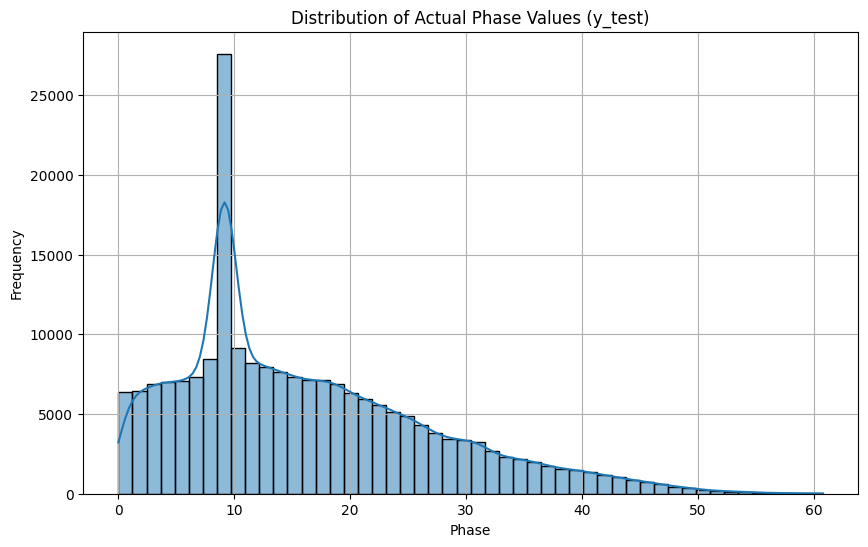


Number of y_test values less than 1.0: 5295 (2.57%) 


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Display descriptive statistics for y_test
print("Descriptive statistics for y_test (Actual Phase values):")
display(y_test.describe())

# Plot histogram of y_test
plt.figure(figsize=(10, 6))
sns.histplot(y_test, bins=50, kde=True)
plt.title('Distribution of Actual Phase Values (y_test)')
plt.xlabel('Phase')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Count values close to zero (e.g., less than a threshold)
threshold = 1.0 # Define a threshold for 'close to zero'
num_small_values = (y_test < threshold).sum()
percentage_small_values = (num_small_values / len(y_test)) * 100

print(f"\nNumber of y_test values less than {threshold}: {num_small_values} ({percentage_small_values:.2f}%) ")

In [ ]:
# 檢查 Phase 欄位中的 0 值與極小值
zero_count = (df_training['Phase'] == 0).sum()
small_value_threshold = 1e-5
near_zero_count = (df_training['Phase'].abs() < small_value_threshold).sum()

print(f"--- Phase 欄位數值檢查 ---")
print(f"數值正好為 0 的樣本數: {zero_count}")
print(f"絕對值小於 {small_value_threshold} 的樣本數: {near_zero_count}")
print(f"Phase 最小值: {df_training['Phase'].min()}")

if zero_count > 0 or near_zero_count > 0:
    print("\n注意：偵測到 0 或極小值，這會導致 MAPE 變得異常高。")

--- Phase 欄位數值檢查 ---
數值正好為 0 的樣本數: 0
絕對值小於 1e-05 的樣本數: 1
Phase 最小值: 9.64903e-06

注意：偵測到 0 或極小值，這會導致 MAPE 變得異常高。


/tmp/ipykernel_658/4265303956.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis')


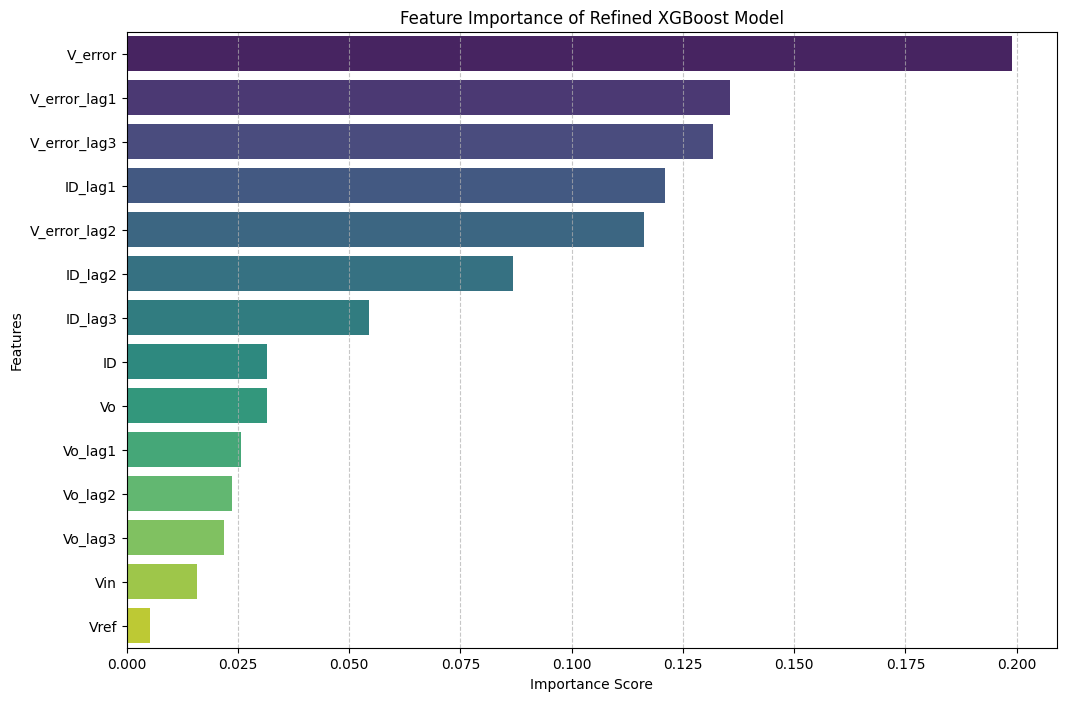

--- 特徵重要性排名 ---


,Feature,Importance
3,V_error,0.199063
6,V_error_lag1,0.135490
12,V_error_lag3,0.131706
7,ID_lag1,0.120984
9,V_error_lag2,0.116150
10,ID_lag2,0.086803
13,ID_lag3,0.054446
4,ID,0.031514
1,Vo,0.031508
5,Vo_lag1,0.025629


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 取得特徵重要性數值
importance_values = xgb_refined.feature_importances_
feature_names = features_deep

# 2. 建立 DataFrame 方便繪圖
fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance_values})
fi_df = fi_df.sort_values(by='Importance', ascending=False)

# 3. 視覺化
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis')
plt.title('Feature Importance of Refined XGBoost Model')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# 4. 顯示數值列表
print("--- 特徵重要性排名 ---")
display(fi_df)

## Step 10: Model Saving and Prediction Example
We use `joblib` to save the model and provide a function for future inference.

In [ ]:
import joblib

# 1. 保存模型與 Scaler
joblib.dump(xgb_refined, 'best_phase_model.pkl')
# 注意：若有使用 scaler，也需保存
# joblib.dump(scaler, 'data_scaler.pkl')

print("模型已保存為 best_phase_model.pkl")

# 2. 單次預測範例函數
def predict_phase(input_data):
    """
    input_data: 包含所有 14 個特徵的 DataFrame (Vin, Vo, Vref, V_error, ID, 以及 Lag 1-3)
    """
    prediction = xgb_refined.predict(input_data)
    return prediction[0]

# 測試顯示一筆測試集中的資料預測結果
test_sample = X_test_d.iloc[[0]]
actual_val = y_test_d.iloc[0]
pred_val = predict_phase(test_sample)

print(f"\n範例測試：")
print(f"實際值 (Actual): {actual_val:.4f}")
print(f"預測值 (Predicted): {pred_val:.4f}")
print(f"誤差 (Error): {abs(actual_val - pred_val):.4f}")

模型已保存為 best_phase_model.pkl

範例測試：
實際值 (Actual): 18.6216
預測值 (Predicted): 15.8582
誤差 (Error): 2.7634
